# Context Feature Feasibility Study (Hybrid v2 Design)

**Read-only diagnostic.** No model training. No new experiments. No synthetic data.

Determines whether a context-enriched Hybrid Prophet + GRU is scientifically justified using the existing Alibaba dataset and prior research (RPA, CSRLE, LFHE, TMA, RLLA).

Documentation: `docs/context_feature_feasibility/`

## 1. Setup

In [17]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

DOCS = REPO_ROOT / 'docs/context_feature_feasibility'
FIGURES = DOCS / 'figures'
CACHE = DOCS / '_analysis_cache'
TMA_DIR = REPO_ROOT / 'experiments/temporal_memory_analysis_2026-07-26_170052'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Repo:', REPO_ROOT)

Repo: /Users/lehaan/Desktop/FYP_Long_Term


## 2. Dataset inspection (Task 1)

In [18]:
train_df = pd.read_parquet(REPO_ROOT / 'data/train_df.parquet')
val_df = pd.read_parquet(REPO_ROOT / 'data/val_df.parquet')
selected = np.load(REPO_ROOT / 'data/selected_containers.npy', allow_pickle=True)

print('Train shape:', train_df.shape)
print('Val shape:', val_df.shape)
print('Columns:', list(train_df.columns))
print('Selected containers:', len(selected))

null_pct = (train_df.isna().mean() * 100).round(1)
null_pct.sort_values(ascending=False)

Train shape: (296576, 19)
Val shape: (74428, 19)
Columns: ['container_id', 'time_stamp', 'cpu_util_percent', 'cpu_usage', 'machine_id', 'mem_util_percent', 'cpi', 'mem_gps', 'mpki', 'net_in', 'net_out', 'disk_io_percent', 'cpu', 'cpu_scaled', 'cpu_mean', 'cpu_std', 'cpu_max', 'cpu_min', 'hour']
Selected containers: 100


cpi                 99.8
mem_gps             99.8
mpki                99.8
net_in              98.4
machine_id          98.4
mem_util_percent    98.4
net_out             98.4
disk_io_percent     98.4
cpu_util_percent    25.6
cpu_mean             0.0
cpu_min              0.0
cpu_max              0.0
cpu_std              0.0
container_id         0.0
cpu_scaled           0.0
cpu                  0.0
time_stamp           0.0
cpu_usage            0.0
hour                 0.0
dtype: float64

In [19]:
schema = pd.DataFrame({
    'column': train_df.columns,
    'dtype': train_df.dtypes.astype(str).values,
    'train_null_pct': (train_df.isna().mean() * 100).round(1).values,
})
hybrid_cols = {'container_id', 'time_stamp', 'cpu_scaled'}
global_cols = hybrid_cols | {'cpu_mean', 'cpu_std'}
schema['used_in_hybrid'] = schema['column'].isin(hybrid_cols)
schema['used_in_global_gru'] = schema['column'].isin(global_cols)
schema

,column,dtype,train_null_pct,used_in_hybrid,used_in_global_gru
0,container_id,str,0.0,True,True
1,time_stamp,datetime64[ms],0.0,True,True
2,cpu_util_percent,float64,25.6,False,False
3,cpu_usage,float64,0.0,False,False
4,machine_id,str,98.4,False,False
5,mem_util_percent,float64,98.4,False,False
6,cpi,float64,99.8,False,False
7,mem_gps,float64,99.8,False,False
8,mpki,float64,99.8,False,False
9,net_in,float64,98.4,False,False


## 3. Prophet-equivalent residuals (read-only, no Prophet.fit)

In [20]:
from utils.tma.data import prophet_equivalent_residuals

cid = 'c_10032'
tr = train_df[train_df.container_id == cid].sort_values('time_stamp')
va = val_df[val_df.container_id == cid].sort_values('time_stamp')

train_res, val_res, full_res = prophet_equivalent_residuals(
    tr.cpu_scaled.values, va.cpu_scaled.values
)
print('Train residuals:', train_res.shape)
print('Val residuals:', val_res.shape)
print('Val residual mean:', val_res.mean(), 'std:', val_res.std())

Train residuals: (614,)
Val residuals: (154,)
Val residual mean: -0.22115376492489422 std: 0.13463745581503073


## 4. Feature derivation examples (Task 2)

In [21]:
def derive_context_features(tr, va, y_tr, y_va, full_res):
    """Example causal feature derivation for one container (no leakage)."""
    ts = pd.concat([tr.time_stamp, va.time_stamp], ignore_index=True)
    cpu = np.concatenate([y_tr, y_va])
    res = full_res
    pred = cpu - res
    s = pd.Series(res)
    p90 = float(tr.cpu_scaled.quantile(0.9))
    out = pd.DataFrame({
        'time_stamp': ts,
        'cpu_scaled': cpu,
        'prophet_pred': pred,
        'residual': res,
        'hour': ts.dt.hour,
        'hour_sin': np.sin(2 * np.pi * ts.dt.hour / 24),
        'hour_cos': np.cos(2 * np.pi * ts.dt.hour / 24),
        'res_roll_std_12': s.rolling(12, min_periods=1).std().fillna(0),
        'res_energy_96': (s ** 2).rolling(96, min_periods=1).mean(),
        'res_lag96': s.shift(96).fillna(0),
        'cpu_std': tr.cpu_std.iloc[0],
        'is_peak_p90': (cpu >= p90).astype(float),
    })
    return out

feat_df = derive_context_features(tr, va, tr.cpu_scaled.values, va.cpu_scaled.values, full_res)
feat_df.tail(8)

Task was destroyed but it is pending!
task: <Task pending name='Task-151' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-152' coro=<Kernel.shell_main() running at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/homebrew/Cellar/python@3.11/3.11.15_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/tokenize.py:454: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  line = readline()
Task was destroyed but it is pending!
task: <Task pending name='Task-152' coro=<Kernel.shell_main() running at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packa

,time_stamp,cpu_scaled,prophet_pred,residual,hour,hour_sin,hour_cos,res_roll_std_12,res_energy_96,res_lag96,cpu_std,is_peak_p90
760,1970-01-09 22:00:00,0.148148,0.547484,-0.399336,22,-0.500000,0.866025,0.043394,0.083659,-0.180098,0.171215,0.0
761,1970-01-09 22:15:00,0.148148,0.541664,-0.393516,22,-0.500000,0.866025,0.043372,0.084955,-0.174278,0.171215,0.0
762,1970-01-09 22:30:00,0.148148,0.541418,-0.393270,22,-0.500000,0.866025,0.025846,0.086251,-0.174032,0.171215,0.0
763,1970-01-09 22:45:00,0.148148,0.546101,-0.397952,22,-0.500000,0.866025,0.025072,0.087568,-0.178715,0.171215,0.0
764,1970-01-09 23:00:00,0.148148,0.553682,-0.405534,23,-0.258819,0.965926,0.021990,0.089009,-0.161605,0.171215,0.0
765,1970-01-09 23:15:00,0.148148,0.561671,-0.413522,23,-0.258819,0.965926,0.014461,0.090571,-0.144902,0.171215,0.0
766,1970-01-09 23:30:00,0.148148,0.568068,-0.419920,23,-0.258819,0.965926,0.014530,0.091989,-0.200682,0.171215,0.0
767,1970-01-09 23:45:00,0.148148,0.571974,-0.423825,23,-0.258819,0.965926,0.014032,0.093682,-0.130514,0.171215,0.0


## 5. Temporal Memory Analysis integration (Task 4)

In [22]:
tma_report = TMA_DIR / 'reports' / 'final_report.json'
if tma_report.exists():
    with tma_report.open() as fh:
        tma = json.load(fh)
    key = tma.get('key_metrics', {})
    pd.DataFrame([{
        'signal': 'CPU original lag-96 ACF',
        'value': key.get('cpu_lag96_acf_mean'),
    }, {
        'signal': 'Prophet-equivalent residual lag-96 ACF',
        'value': key.get('prophet_lag96_acf_mean'),
    }, {
        'signal': 'Hybrid post-forecast decorrelation steps',
        'value': key.get('hybrid_error_memory_steps'),
    }])
else:
    print('TMA report not found — see docs/temporal_memory_analysis/')

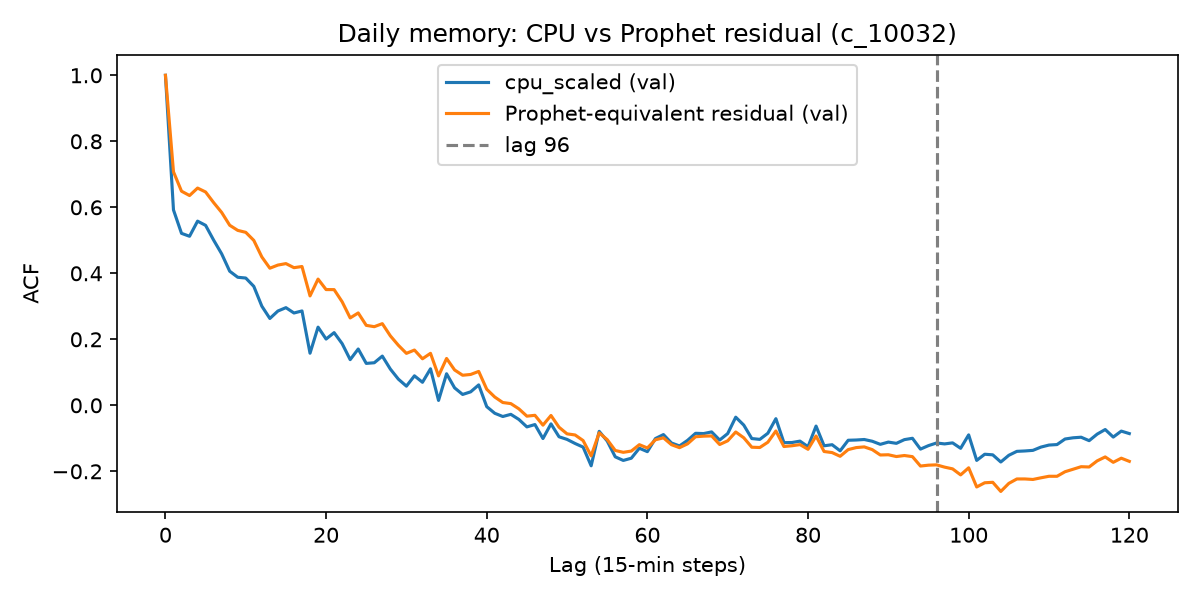

In [23]:
acf_path = FIGURES / 'acf_cpu_vs_prophet_residual_example.png'
if acf_path.exists():
    display(Image(filename=str(acf_path)))
else:
    from statsmodels.tsa.stattools import acf
    acf_cpu = acf(va.cpu_scaled.values, nlags=120, fft=True)
    acf_res = acf(val_res, nlags=120, fft=True)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(acf_cpu, label='cpu_scaled')
    ax.plot(acf_res, label='Prophet-equivalent residual')
    ax.axvline(96, color='gray', ls='--', label='lag 96')
    ax.legend(); ax.set(xlabel='Lag', ylabel='ACF'); plt.show()

## 6. Correlation analysis — context vs residual (Task 3, 6)

In [24]:
ctx_csv = CACHE / 'context_feature_residual_correlation.csv'
if ctx_csv.exists():
    ctx_summary = pd.read_csv(ctx_csv)
else:
    rows = []
    for cid in selected:
        tr_i = train_df[train_df.container_id == cid].sort_values('time_stamp')
        va_i = val_df[val_df.container_id == cid].sort_values('time_stamp')
        if len(tr_i) < 200 or len(va_i) < 50:
            continue
        y_tr, y_va = tr_i.cpu_scaled.values, va_i.cpu_scaled.values
        _, _, full = prophet_equivalent_residuals(y_tr, y_va)
        fd = derive_context_features(tr_i, va_i, y_tr, y_va, full)
        sub = fd.iloc[len(tr_i):]
        for col in sub.columns:
            if col in {'time_stamp', 'cpu_scaled', 'prophet_pred', 'residual'}:
                continue
            if sub[col].std() < 1e-12:
                continue
            r = np.corrcoef(sub[col], sub['residual'])[0, 1]
            rows.append({'feature': col, 'pearson_r': r, 'container_id': cid})
    ctx_summary = pd.DataFrame(rows).groupby('feature')['pearson_r'].agg(['mean','std']).reset_index()
    ctx_summary['abs_mean'] = ctx_summary['mean'].abs()

ctx_summary.sort_values('abs_mean', ascending=False)

,feature,mean,std,count,abs_mean
0,cpu_scaled,7.708142e-01,2.717017e-01,97,7.708142e-01
1,is_peak,6.264553e-01,1.500827e-01,93,6.264553e-01
2,res_roll_std_12,1.551029e-01,2.249549e-01,99,1.551029e-01
3,res_lag96,1.180977e-01,2.433774e-01,99,1.180977e-01
4,prophet_pred,-7.137257e-02,3.290435e-01,99,7.137257e-02
5,res_energy_96,6.661525e-02,2.032980e-01,99,6.661525e-02
6,hour,1.700686e-02,1.847526e-01,99,1.700686e-02
7,cpu_std,1.637806e-18,5.305755e-17,62,1.637806e-18


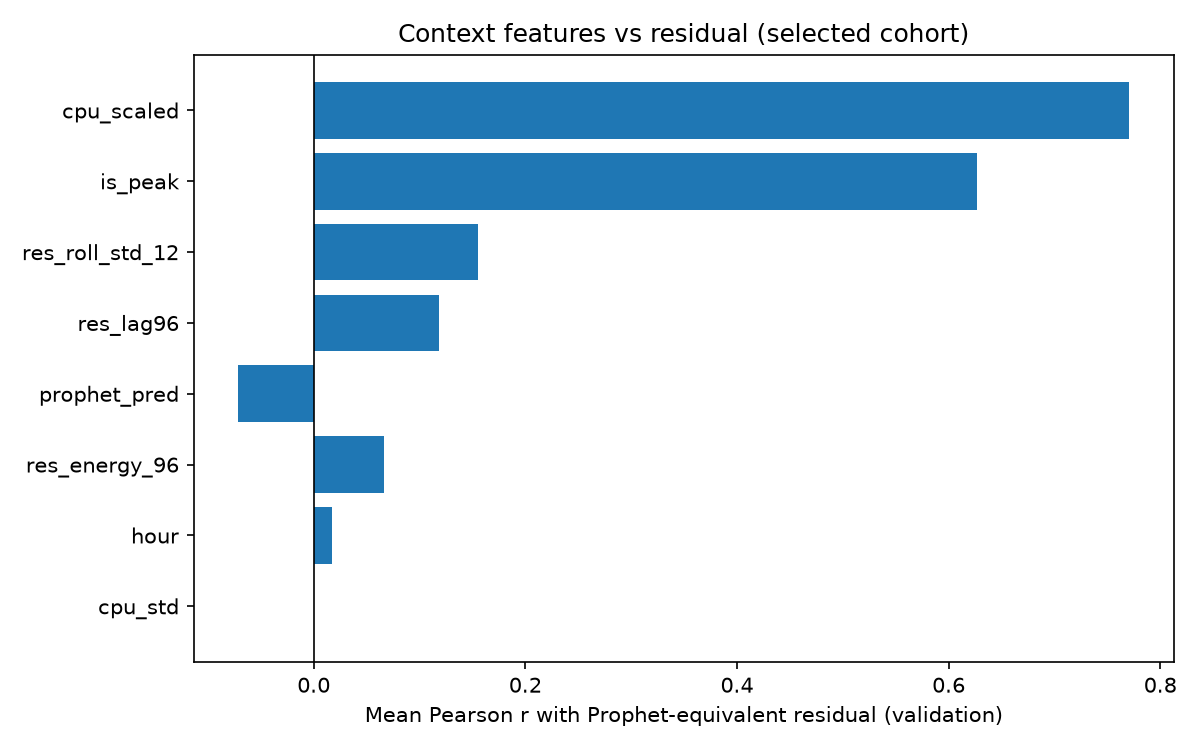

In [25]:
fig_path = FIGURES / 'context_feature_residual_correlation.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    plot_df = ctx_summary.sort_values('abs_mean')
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(plot_df['feature'], plot_df['mean'])
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title('Context feature correlation with residual')
    plt.show()

## 7. Residual-derived redundancy (Task 5–6)

,feature,mean,std,count,abs_mean
0,res_ewm_mean_12,0.608573,0.105086,20,0.608573
1,res_roll_mean_6,0.537279,0.158797,20,0.537279
2,res_diff1,0.534903,0.119137,20,0.534903
3,res_slope_12,0.476506,0.055780,20,0.476506
4,res_roll_mean_12,0.404776,0.185560,20,0.404776
5,res_lag1,0.399070,0.203123,20,0.399070
6,res_roll_mean_24,0.285853,0.167272,20,0.285853
7,res_diff2,0.228136,0.081946,20,0.228136
8,res_ewm_var_12,0.181722,0.268143,20,0.181722
9,res_roll_std_6,0.175271,0.203512,20,0.175271


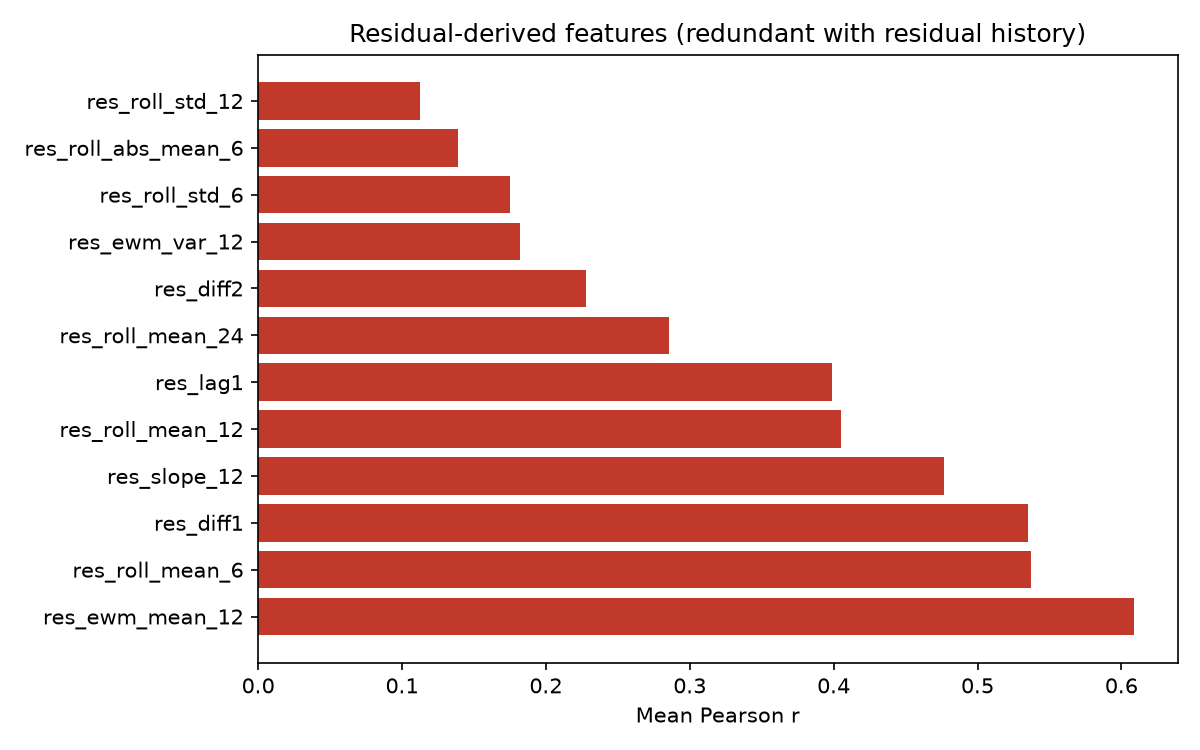

In [26]:
red_path = CACHE / 'feature_residual_correlation_summary.csv'
if red_path.exists():
    redundant = pd.read_csv(red_path)
    display(redundant.sort_values('abs_mean', ascending=False).head(12))
    display(Image(filename=str(FIGURES / 'residual_derived_feature_correlation.png')))
else:
    Markdown('Run read-only analysis script to populate cache (see docs README).')

**Interpretation:** High correlation for rolling mean, diff, and lag features reflects algebraic dependence on the residual series — the GRU already receives 96 consecutive residuals. These are **redundant channels**, not new information.

## 8. Inter-feature correlation — compact set (Task 6)

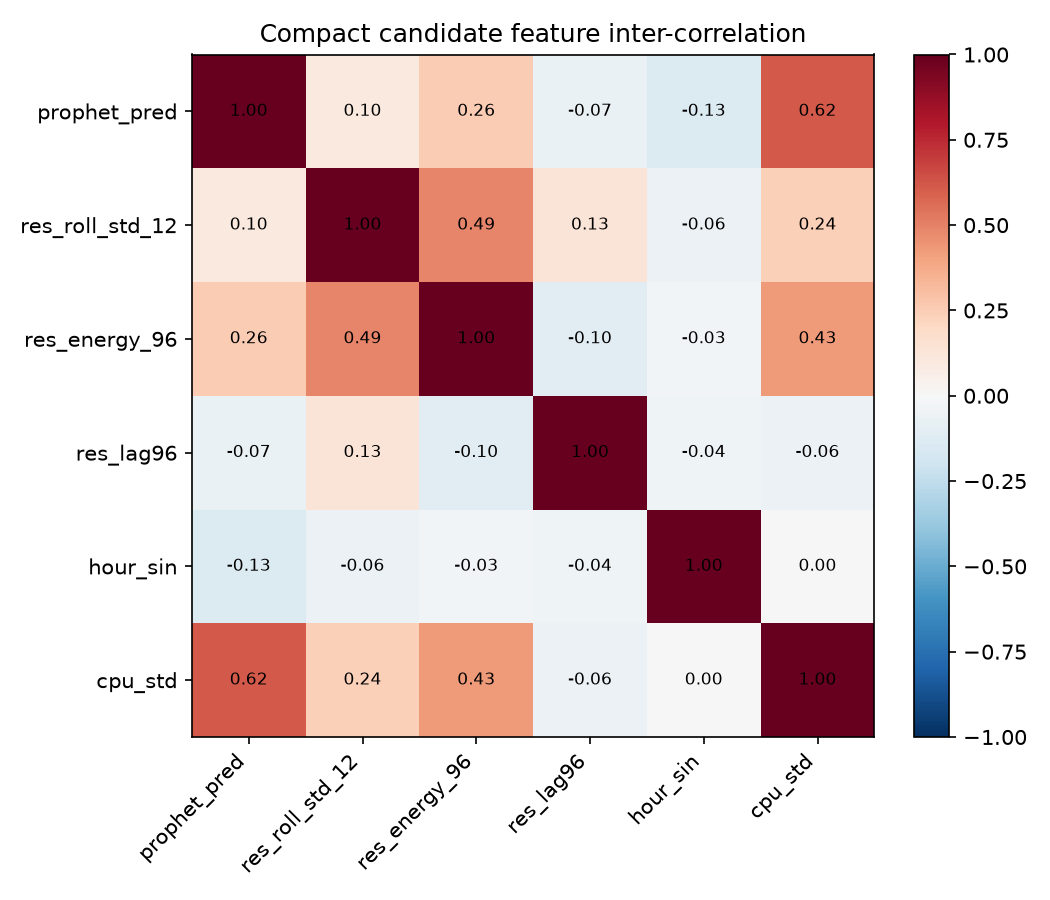

In [27]:
compact_path = FIGURES / 'compact_feature_intercorrelation.png'
if compact_path.exists():
    display(Image(filename=str(compact_path)))
else:
    pool = []
    for cid in selected[:10]:
        tr_i = train_df[train_df.container_id == cid].sort_values('time_stamp')
        va_i = val_df[val_df.container_id == cid].sort_values('time_stamp')
        y_tr, y_va = tr_i.cpu_scaled.values, va_i.cpu_scaled.values
        _, _, full = prophet_equivalent_residuals(y_tr, y_va)
        fd = derive_context_features(tr_i, va_i, y_tr, y_va, full)
        pool.append(fd.iloc[len(tr_i):][[
            'prophet_pred','res_roll_std_12','res_energy_96','res_lag96','hour_sin','cpu_std'
        ]])
    cm = pd.concat(pool, ignore_index=True).corr()
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(cm.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(cm.columns)), cm.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(cm.columns)), cm.columns)
    for i in range(len(cm)):
        for j in range(len(cm)):
            ax.text(j, i, f'{cm.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    ax.set_title('Compact candidate inter-correlation')
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

## 9. Comparison tables

In [28]:
comparison = pd.DataFrame([
    {'feature': 'residual_scaled', 'new_info': 'baseline', 'prophet_dup': 'No',
     'tma_support': '96-step window OK', 'recommended': 'Yes (ch0)'},
    {'feature': 'prophet_yhat_scaled', 'new_info': 'Level/regime', 'prophet_dup': 'Partial',
     'tma_support': 'Level not in residual', 'recommended': 'Yes (ch1)'},
    {'feature': 'res_roll_std_12', 'new_info': 'Local volatility', 'prophet_dup': 'No',
     'tma_support': 'Short-memory vol', 'recommended': 'Yes (ch2)'},
    {'feature': 'cpu_std', 'new_info': 'Container scale', 'prophet_dup': 'No',
     'tma_support': 'Global GRU precedent', 'recommended': 'Yes (ch3)'},
    {'feature': 'is_peak_p90', 'new_info': 'Peak regime', 'prophet_dup': 'No',
     'tma_support': 'Peak-aware precedent', 'recommended': 'Yes (ch4)'},
    {'feature': 'hour_sin/cos', 'new_info': 'Calendar', 'prophet_dup': 'High',
     'tma_support': 'lag-96 ACF ~ 0.04', 'recommended': 'Optional ablation'},
    {'feature': 'res_roll_mean_12', 'new_info': 'None (derivable)', 'prophet_dup': 'No',
     'tma_support': 'Redundant with window', 'recommended': 'No'},
    {'feature': 'mem_util_percent', 'new_info': 'Unknown', 'prophet_dup': 'No',
     'tma_support': '98% missing', 'recommended': 'No'},
])
comparison

,feature,new_info,prophet_dup,tma_support,recommended
0,residual_scaled,baseline,No,96-step window OK,Yes (ch0)
1,prophet_yhat_scaled,Level/regime,Partial,Level not in residual,Yes (ch1)
2,res_roll_std_12,Local volatility,No,Short-memory vol,Yes (ch2)
3,cpu_std,Container scale,No,Global GRU precedent,Yes (ch3)
4,is_peak_p90,Peak regime,No,Peak-aware precedent,Yes (ch4)
5,hour_sin/cos,Calendar,High,lag-96 ACF ~ 0.04,Optional ablation
6,res_roll_mean_12,None (derivable),No,Redundant with window,No
7,mem_util_percent,Unknown,No,98% missing,No


## 10. Hybrid v2 input representation (Task 7)

In [29]:
tensor_doc = pd.DataFrame({
    'channel': [0, 1, 2, 3, 4],
    'name': ['residual_scaled', 'prophet_yhat_scaled', 'res_roll_std_12', 'cpu_std', 'is_peak_p90'],
    'shape_per_step': ['scalar', 'scalar', 'scalar', 'scalar (broadcast)', 'binary'],
    'window': ['t-95..t', 't-95..t', 't-95..t', 'constant', 't-95..t'],
})
print('Input tensor shape per sequence: (96, 5)')
tensor_doc

Input tensor shape per sequence: (96, 5)


,channel,name,shape_per_step,window
0,0,residual_scaled,scalar,t-95..t
1,1,prophet_yhat_scaled,scalar,t-95..t
2,2,res_roll_std_12,scalar,t-95..t
3,3,cpu_std,scalar (broadcast),constant
4,4,is_peak_p90,binary,t-95..t


In [30]:
# Illustrative slice (last 5 steps of 96-step window)
window = feat_df.iloc[len(tr)-5:len(tr)+1].copy()
window['residual_scaled'] = (window['residual'] - train_res.mean()) / train_res.std()
cols = ['residual_scaled', 'prophet_pred', 'res_roll_std_12', 'cpu_std', 'is_peak_p90']
window[cols].round(3)

,residual_scaled,prophet_pred,res_roll_std_12,cpu_std,is_peak_p90
609,-1.618,0.472,0.093,0.171,0.0
610,-1.365,0.469,0.095,0.171,0.0
611,-1.072,0.462,0.091,0.171,0.0
612,-0.749,0.452,0.089,0.171,0.0
613,-0.760,0.440,0.087,0.171,0.0
614,-0.792,0.431,0.084,0.171,0.0


## 11. Feature importance — conceptual only (Task 8)

No model training in this study. Conceptual importance based on research chain:

| Evidence | Implication |
|----------|-------------|
| RPA: Ljung–Box reject 73.7% | Structure exists — GRU should benefit if given right inputs |
| CSRLE: GRU learns synthetic B0 | Architecture capable; real signal weaker |
| LFHE: r did not improve with DA-MSE | Context alone may not fix objective issue |
| TMA: residual lag-96 ≈ 0.04 | Calendar features low priority |
| RLLA: linear r ≈ 0.02–0.06 | Upper bound on easy linear gains is low |

**Conceptual ranking:** prophet level > volatility > peak regime > cpu_std > calendar

## 12. Prior research metrics (frozen references)

In [31]:
prior = pd.DataFrame([
    {'study': 'RPA', 'metric': 'Ljung-Box reject rate', 'value': '~73.7%'},
    {'study': 'RPA', 'metric': 'Hybrid GRU residual Pearson r', 'value': '~0.02'},
    {'study': 'CSRLE', 'metric': 'GRU learns synthetic B0', 'value': 'Yes'},
    {'study': 'LFHE', 'metric': 'DA-MSE std ratio change', 'value': '+0.73'},
    {'study': 'LFHE', 'metric': 'DA-MSE Pearson r change', 'value': '0.113→0.087'},
    {'study': 'TMA', 'metric': 'CPU lag-96 ACF', 'value': '~0.33'},
    {'study': 'TMA', 'metric': 'Prophet residual lag-96 ACF', 'value': '~0.04'},
    {'study': 'RLLA', 'metric': 'Ridge best Pearson r (real)', 'value': '~0.059'},
    {'study': 'Ridge audit', 'metric': 'Ridge std ratio B0', 'value': '~0.22'},
    {'study': 'Ridge audit', 'metric': 'GRU std ratio B0', 'value': '~0.07'},
])
prior

,study,metric,value
0,RPA,Ljung-Box reject rate,~73.7%
1,RPA,Hybrid GRU residual Pearson r,~0.02
2,CSRLE,GRU learns synthetic B0,Yes
3,LFHE,DA-MSE std ratio change,+0.73
4,LFHE,DA-MSE Pearson r change,0.113→0.087
5,TMA,CPU lag-96 ACF,~0.33
6,TMA,Prophet residual lag-96 ACF,~0.04
7,RLLA,Ridge best Pearson r (real),~0.059
8,Ridge audit,Ridge std ratio B0,~0.22
9,Ridge audit,GRU std ratio B0,~0.07


## 13. Final conclusions

### Explicit answers

1. **Dataset sufficient?** Yes for CPU-side context; no for multivariate telemetry.

2. **Genuinely new features?** `prophet_yhat_scaled`, `res_roll_std_12`, `cpu_std`, `is_peak_p90`. Calendar and residual-transform features are largely duplicative.

3. **Recommended 3–5 features:** prophet_yhat_scaled, res_roll_std_12, cpu_std, is_peak_p90 (+ optional hour_sin/cos).

4. **Scientifically justified?** **Yes, conditionally** — investigate compact Hybrid v2; expect incremental not breakthrough gains (RLLA, LFHE).

See `docs/context_feature_feasibility/summary.md` for full narrative.